In [157]:
import os
import cv2
import sklearn
import pandas as pd
import numpy as np,random
import seaborn as sn
import tensorflow as tf
from sklearn.svm import SVC
from keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.svm import LinearSVC
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import BatchNormalization,MaxPooling2D,Conv2D,Flatten,Dense,Dropout


In [158]:
path_of_dir=os.listdir('../brain tumor/')
classes_in_dir={'Healthy':0,'Brain Tumor':1}

classes_in_dir

{'Healthy': 0, 'Brain Tumor': 1}

In [159]:
import cv2
import numpy as np

def safe_augment(img):
    h, w = img.shape[:2]

    # 1. Fixed rotation (e.g., 5 degrees)
    angle = 5
    M_rot = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    img = cv2.warpAffine(img, M_rot, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Fixed zoom (e.g., 1.05x)
    zf = 1.05
    zh, zw = int(h*zf), int(w*zf)
    img = cv2.resize(img, (zw, zh))
    start_y = max((zh - h)//2, 0)
    start_x = max((zw - w)//2, 0)
    img = img[start_y:start_y+h, start_x:start_x+w]

    # 3. Fixed brightness (+10)
    beta = 10
    img = cv2.convertScaleAbs(img, alpha=1.0, beta=beta)

    # 4. Fixed gamma (1.05)
    gamma = 1.05
    img = np.power(img / 255.0, gamma) * 255
    img = img.astype(np.uint8)

    # 5. Always apply Gaussian blur
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # 6. Always flip horizontally
    img = cv2.flip(img, 1)

    return img



X, Y = [], []

for i in classes_in_dir:
    path = '../brain tumor/' + i
    for j in os.listdir(path):
        pic = cv2.imread(path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        pic = safe_augment(pic)
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        X.append(pic)
        Y.append(classes_in_dir[i])

       


In [160]:
x = np.array(X, dtype='float32').reshape(-1, 200, 200, 1) / 255.0  # normalize
y = np.array(Y)
x, y = shuffle(x, y, random_state=42)

In [161]:
pd.Series(y).value_counts()

0    2500
1    2500
Name: count, dtype: int64

In [162]:
y.shape

(5000,)

In [163]:
x.shape

(5000, 200, 200, 1)

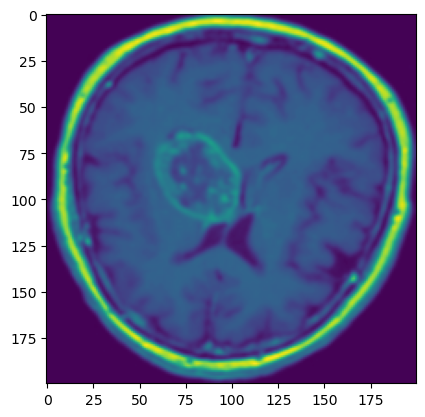

In [164]:
plt.imshow(x[1])


In [165]:
x.shape

(5000, 200, 200, 1)

In [166]:
x_train3D,x_test3D,y_train3D,y_test3D=train_test_split(x ,y,random_state=42,test_size=0.20)

Text(0.5, 0, '0')

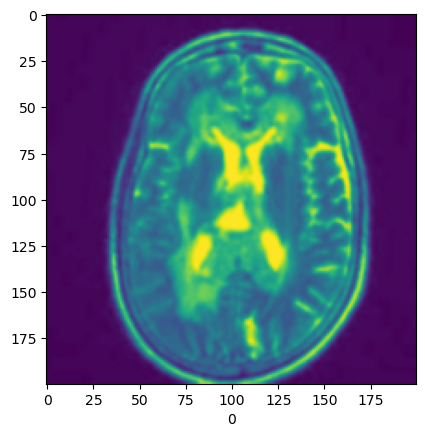

In [167]:
plt.imshow(x_test3D[5])
plt.xlabel(y_test3D[5])


In [168]:
x_train3D.shape

(4000, 200, 200, 1)

#CNN MODEL

In [169]:
cnn=Sequential([keras.layers.Input(shape=(200,200,1)),
Conv2D(filters=32, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Conv2D(filters=64, kernel_size=(3, 3), activation='relu'), # convolutional layer
BatchNormalization(),
MaxPooling2D(), # pooling layer

Flatten(),
Dense(1, activation='sigmoid')

])

cnn.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 198, 198, 32)      320       
                                                                 
 batch_normalization_2 (Batc  (None, 198, 198, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 99, 99, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 batch_normalization_3 (Batc  (None, 97, 97, 64)       256       
 hNormalization)                                                 
                                                      

In [170]:
cnn.compile(optimizer=Adam(learning_rate=1e-4),loss='binary_crossentropy', metrics=['accuracy'])

In [171]:
cnn.fit(x_train3D,y_train3D,validation_data=(x_test3D,y_test3D), epochs=3, batch_size=16)

Epoch 1/3
250/250 [==============================] - 74s 293ms/step - loss: 0.4773 - accuracy: 0.8385 - val_loss: 0.5213 - val_accuracy: 0.8200
Epoch 2/3
250/250 [==============================] - 73s 291ms/step - loss: 0.1660 - accuracy: 0.9413 - val_loss: 0.2163 - val_accuracy: 0.9150
Epoch 3/3
250/250 [==============================] - 73s 292ms/step - loss: 0.0814 - accuracy: 0.9712 - val_loss: 0.1642 - val_accuracy: 0.9510


In [172]:
test_loss,test_acc=cnn.evaluate(x_test3D,y_test3D,verbose=2)

32/32 - 4s - loss: 0.1642 - accuracy: 0.9510 - 4s/epoch - 140ms/step


In [173]:
pred1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()

32/32 [==============================] - 5s 137ms/step


In [174]:
print(pred1[0:20])

[0 0 0 1 1 0 1 1 0 1 0 0 0 1 1 0 0 1 0 1]


In [175]:
accuracy_score(y_test3D,pred1)

0.951

In [176]:
conf_mat= confusion_matrix(y_test3D,pred1)
print(classification_report(y_test3D,pred1))


              precision    recall  f1-score   support

           0       0.96      0.93      0.95       476
           1       0.94      0.97      0.95       524

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000



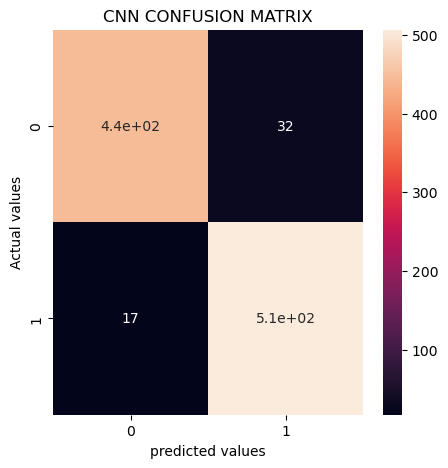

In [177]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("CNN CONFUSION MATRIX")
plt.show()

#Random forest

In [178]:
x_updated=x.reshape(len(x),-1)

In [179]:
x_updated.shape

(5000, 40000)

In [180]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_updated)

In [181]:
x_train2D,x_test2D,y_train2D,y_test2D=train_test_split(x_scaled,y,random_state=42,test_size=0.20)

In [182]:
x_train2D.shape

(4000, 40000)

In [261]:
rf= RandomForestClassifier()
rf.fit(x_train2D, y_train2D)

RandomForestClassifier()

In [262]:
pred2=rf.predict(x_test2D)

In [263]:
accuracy_score(y_test2D,pred2)

0.947

In [186]:

conf_mat2=confusion_matrix(y_test2D,pred2)


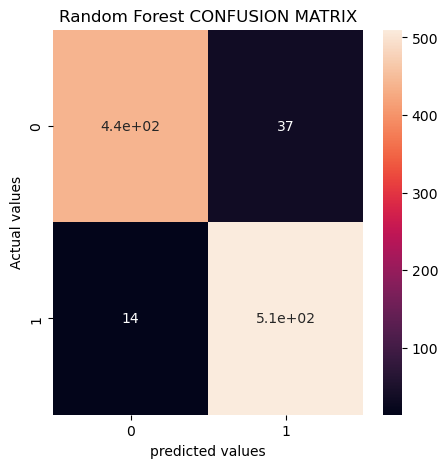

In [187]:
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat2,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Random Forest CONFUSION MATRIX")
plt.show()

#SVM

In [188]:
svm_pipeline = Pipeline([
    ('pca', PCA(n_components=1000)),        # reduce to 500 features
    ('svm', LinearSVC(C=1.0, max_iter=2000, tol=1e-3))  # fewer iterations needed
])

svm_pipeline.fit(x_train2D, y_train2D)
pred3 =svm_pipeline.predict(x_test2D)



In [189]:
accuracy_score(y_test2D,pred3)

0.899

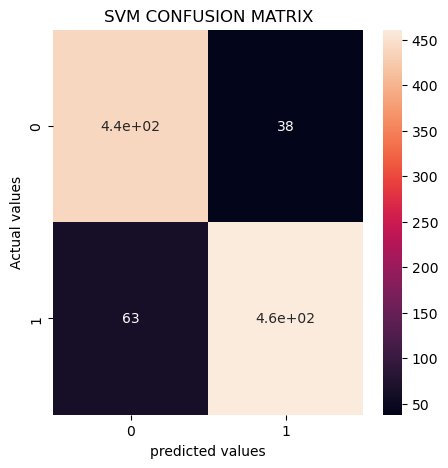

In [190]:
conf_mat3=confusion_matrix(y_test2D,pred3)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat3,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("SVM CONFUSION MATRIX")
plt.show()

#KNN

In [257]:
knn =KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(x_train2D, y_train2D) 

KNeighborsClassifier(weights='distance')

In [258]:
pred4=knn.predict(x_test2D)

In [193]:
#evaluting the model
accuracy_score(y_test2D,pred4)

0.932

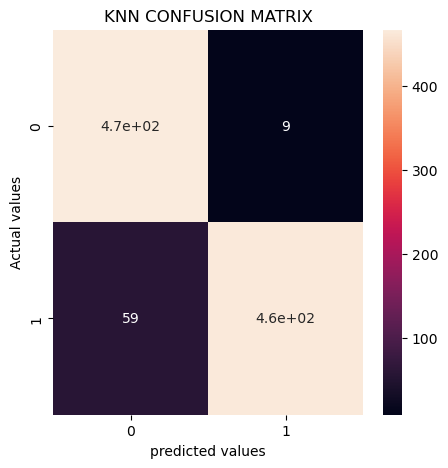

In [259]:
conf_mat4=confusion_matrix(y_test2D,pred4)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat4,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("KNN CONFUSION MATRIX")
plt.show()

#Logistic Regression

In [254]:
LR = LogisticRegression(max_iter=10000, solver='lbfgs')
LR.fit(x_train2D, y_train2D)

LogisticRegression(max_iter=10000)

In [255]:
pred5 = LR.predict(x_test2D)

print("Accuracy:", accuracy_score(y_test2D, pred5))
print("\nClassification Report:\n", classification_report(y_test2D, pred5))

Accuracy: 0.926

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.92       476
           1       0.94      0.92      0.93       524

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



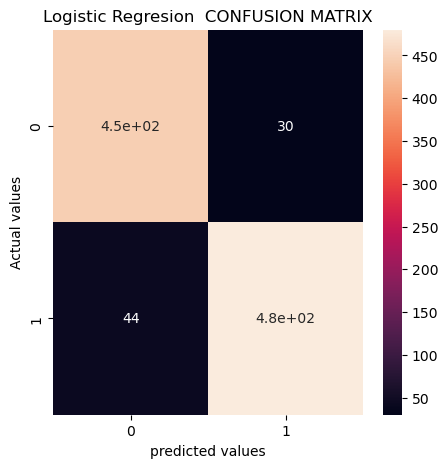

In [256]:
conf_mat5= confusion_matrix(y_test2D,pred5)
plt.figure(figsize=(5,5))
sn.heatmap(conf_mat5,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Logistic Regresion  CONFUSION MATRIX")
plt.show()

# ALL PREDICTED VALUES

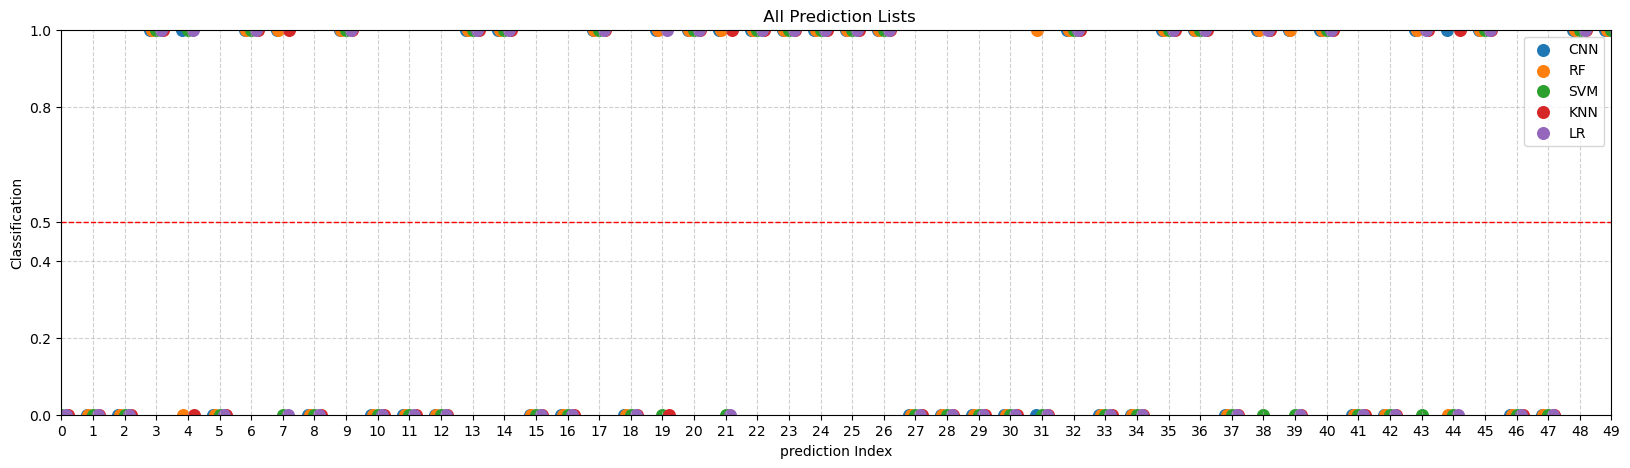

In [268]:
sze=np.arange(len(pred1))
plt.figure(figsize=(20,5))
plt.scatter(sze - 0.2, pred1, label='CNN', alpha=1, s=70)
plt.scatter(sze - 0.15, pred2, label='RF', alpha=1, s=70)
plt.scatter(sze, pred3, label='SVM', alpha=1, s=70)
plt.scatter(sze + 0.2, pred4, label='KNN', alpha=1, s=70)
plt.scatter(sze + 0.15 , pred5, label='LR', alpha=1, s=70)

plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)

plt.ylim(0,1)
plt.xlim(0,10)
plt.xticks(range(0,50))
plt.yticks([0, 0.2,0.4,0.5,0.8,1])
plt.xlabel('prediction Index')
plt.ylabel('Classification')
plt.title(' All Prediction Lists')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [269]:
pp1=(cnn.predict(x_test3D)>0.5).astype('int').flatten()
pp2=rf.predict(x_test2D)
pp3=svm_pipeline.predict(x_test2D)
pp4=knn.predict(x_test2D)
pp5=LR.predict(x_test2D)

32/32 [==============================] - 4s 138ms/step


In [270]:
print(pp1[0:2])

[0 0]


In [271]:
total_prediction=[]
for i in range(len(pp3)):
    totaladd=pp1[i]+pp2[i]+pp3[i]+pp4[i]+pp5[i]
    total_prediction.append(totaladd)


In [272]:
Ensemble_prediction = [1 if val >= 3 else 0 for val in total_prediction]
print(Ensemble_prediction[:6])

[0, 0, 0, 1, 1, 0]


In [279]:
print(y_test2D[0:6])

[0 0 0 1 1 0]


In [274]:
print(pred1[0:6])

[0 0 0 1 1 0]


In [275]:
print(pred2[0:6])

[0 0 0 1 0 0]


In [276]:
print(pred3[0:6])

[0 0 0 1 1 0]


In [277]:
print(pred4[0:6])

[0 0 0 1 0 0]


In [278]:
print(pred5[0:6])

[0 0 0 1 1 0]


In [282]:
g=np.where(y_test2D != Ensemble_prediction)[0]
print(g)

[ 44  56  96 113 117 135 139 184 199 261 276 306 325 385 388 431 444 574
 602 637 659 678 688 691 706 707 721 738 757 774 783 793 828 829 859 860
 882 905 909 914 945 978]


In [283]:
print("Accuracy:", accuracy_score(y_test2D, Ensemble_prediction))
print("\nClassification Report:\n", classification_report(y_test2D, Ensemble_prediction))

Accuracy: 0.958

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.96       476
           1       0.95      0.97      0.96       524

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



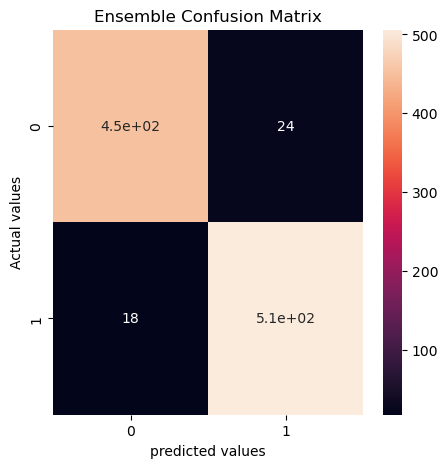

In [284]:
ensemble_confusion_matrix= confusion_matrix(y_test2D,Ensemble_prediction)
plt.figure(figsize=(5,5))
sn.heatmap(ensemble_confusion_matrix,annot=True)
plt.xlabel('predicted values')
plt.ylabel("Actual values")
plt.title("Ensemble Confusion Matrix")
plt.show()

In [431]:
x_pred, y_pred = [], []
img_path = r"D:\My Final Work\external_pic" 
for j in os.listdir(img_path):
        pic = cv2.imread(img_path + '/' + j, cv2.IMREAD_GRAYSCALE)  # Force grayscale
        pic = cv2.resize(pic, (200, 200))                       # Force size
        pic = np.array(pic, dtype='float32')
        if pic.shape != (200, 200):
            pic = cv2.resize(pic, (200, 200))

        x_pred.append(pic)
        y_pred.append(j)


(-0.5, 199.5, 199.5, -0.5)

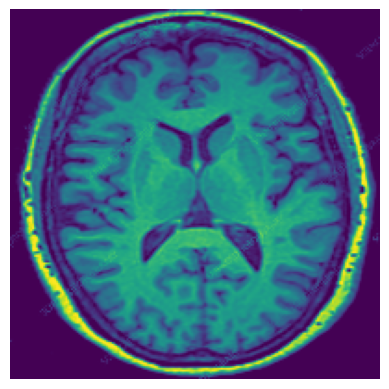

In [432]:
plt.imshow(x_pred[1])
plt.axis('off')

In [433]:
ensemble_data = []

for k in os.listdir(img_path):
    file_path = os.path.join(img_path, k)

    # ---- Load image once ----
    img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)   # grayscale
    img = cv2.resize(img, (200, 200))                   # resize same as training

    # ---- CNN preprocessing ----
    check_img3d = safe_augment(img)                     # pass array
    cnnpred1 = check_img3d.reshape(1, 200, 200, 1)
    cnnpred = cnnpred1 / 255.0

    # ---- Classical models preprocessing ----
    unseen_img2d = img.reshape(1, -1)                   # flatten to 1D row
    x_scaled = scaler.transform(unseen_img2d)           # use training scaler

    # ---- Predictions ----
    p1 = int((cnn.predict(cnnpred) > 0.5).astype('int')[0][0])
    p2 = int(rf.predict(x_scaled)[0])
    p3 = int(svm_pipeline.predict(x_scaled)[0])
    p4 = int(LR.predict(x_scaled)[0])
    p5 = int(knn.predict(x_scaled)[0])

    # ---- Majority Voting ----
    if p1 + p2 + p3 + p4 + p5 >= 3:
        print(f"{k} -> Tumor")
        ensemble_data.append('Tumor')
    else:
        print(f"{k} -> No Tumor")
        ensemble_data.append('Not Tumor')


1/1 [==============================] - 0s 35ms/step
1.jpg -> No Tumor
1/1 [==============================] - 0s 35ms/step
10.jpg -> Tumor
1/1 [==============================] - 0s 33ms/step
11.png -> No Tumor
1/1 [==============================] - 0s 35ms/step
12.jpg -> No Tumor
1/1 [==============================] - 0s 30ms/step
13.jpeg -> No Tumor
1/1 [==============================] - 0s 83ms/step
2.jpeg -> No Tumor
1/1 [==============================] - 0s 34ms/step
3.jpg -> Tumor
1/1 [==============================] - 0s 35ms/step
4.png -> Tumor
1/1 [==============================] - 0s 26ms/step
5.png -> Tumor
1/1 [==============================] - 0s 28ms/step
6.jpeg -> Tumor
1/1 [==============================] - 0s 26ms/step
7.jpeg -> Tumor
1/1 [==============================] - 0s 27ms/step
8.jpg -> No Tumor
1/1 [==============================] - 0s 32ms/step
9.jpg -> Tumor


In [448]:
img_path2 = r"D:\My Final Work\external_pic/8.jpg" 
pic1 = cv2.imread(img_path2 , cv2.IMREAD_GRAYSCALE)  # Force grayscale
pic1= cv2.resize(pic, (200, 200))                       # Force size
pic1 = np.array(pic, dtype='float32')


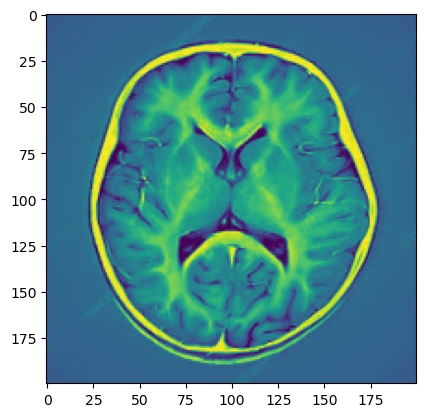

In [449]:
plt.imshow(pic1)

In [450]:
cnnpred1=safe_augment(pic1)

In [451]:
cnnpred1 = pic1.reshape(1, 200, 200, 1)
cnnpred = cnnpred1 / 255.0

In [452]:
cnnpred.shape

(1, 200, 200, 1)

In [453]:
p11 = (cnn.predict(cnnpred) > 0.5).astype('int').flatten()

1/1 [==============================] - 0s 48ms/step


In [454]:
print(p11)

[0]


In [455]:
p_2D=cnnpred.reshape(1, -1)
p_2D.shape

(1, 40000)

In [456]:
scaler1 = StandardScaler()
x_scaled = scaler1.fit_transform(p_2D)

In [457]:
p22=rf.predict(x_scaled)
p33=svm_pipeline.predict(x_scaled)
p44=LR.predict(x_scaled)
p55 = knn.predict(x_scaled)
print('CNN =',p11)
print('RF =',p22)
print('SVM =',p33)
print('LR =',p44)
print('KNN =',p55)

if(p11+p22+p33+p44+p55 >= 3):
    print(" \n Tumor")
elif (p11+p22+p33+p44+p55 < 3):
    print( "\n No Tumor")

CNN = [0]
RF = [1]
SVM = [1]
LR = [0]
KNN = [0]

 No Tumor
